# 人脸关键点定位与 LFW 人脸验证

本 Notebook 对应任务 2.4 及最终交付要求：使用 YuNet 对测试图像进行人脸检测和 5 点定位，并使用 SFace 预训练模型在 LFW 数据集上计算人脸验证准确率。

## 1. 方法说明

这里 **YuNet** 预训练模型。YuNet 会同时输出人脸框、置信度和 5 个关键点：

1. 右眼
2. 左眼
3. 鼻尖
4. 右嘴角
5. 左嘴角

In [2]:
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("OpenCV:", cv2.__version__)
assert hasattr(cv2, "FaceDetectorYN"), "当前 OpenCV 不支持 FaceDetectorYN,请安装 opencv-python>=4.5.4"
assert hasattr(cv2, "FaceRecognizerSF"), "当前 OpenCV 不支持 FaceRecognizerSF,请安装 opencv-python>=4.5.4"

OpenCV: 4.10.0


## 2. 准备测试图像

优先读取 `face_recognition/test_images/` 中的图片；如果该目录为空，则自动选取 LFW 数据集中的前 3 张图片。

In [3]:
WORKING_DIR = Path.cwd().resolve()
PROJECT_ROOT = WORKING_DIR.parent if WORKING_DIR.name == "face_recognition" else WORKING_DIR

TEST_IMAGE_DIR = PROJECT_ROOT / "face_recognition" / "test_images"
OUTPUT_DIR = PROJECT_ROOT / "face_recognition" / "outputs" / "face_landmarks"
MODEL_DIR = PROJECT_ROOT / "data" / "models"
TEST_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

supported_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_paths = sorted(
    path for path in TEST_IMAGE_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in supported_extensions
)

if not image_paths:
    lfw_dir = PROJECT_ROOT / "data" / "lfw" / "lfw-deepfunneled"
    image_paths = sorted(lfw_dir.glob("*/*.jpg")) if lfw_dir.exists() else []

assert image_paths, f"请先把测试图片放入：{TEST_IMAGE_DIR}"
IMAGE_PATHS = image_paths[:3]

print(f"本次测试 {len(IMAGE_PATHS)} 张图片：")
for image_path in IMAGE_PATHS:
    print("-", image_path)

本次测试 3 张图片：
- D:\InternProject\face-vision-lab\data\lfw\lfw-deepfunneled\Aaron_Eckhart\Aaron_Eckhart_0001.jpg
- D:\InternProject\face-vision-lab\data\lfw\lfw-deepfunneled\Aaron_Guiel\Aaron_Guiel_0001.jpg
- D:\InternProject\face-vision-lab\data\lfw\lfw-deepfunneled\Aaron_Patterson\Aaron_Patterson_0001.jpg


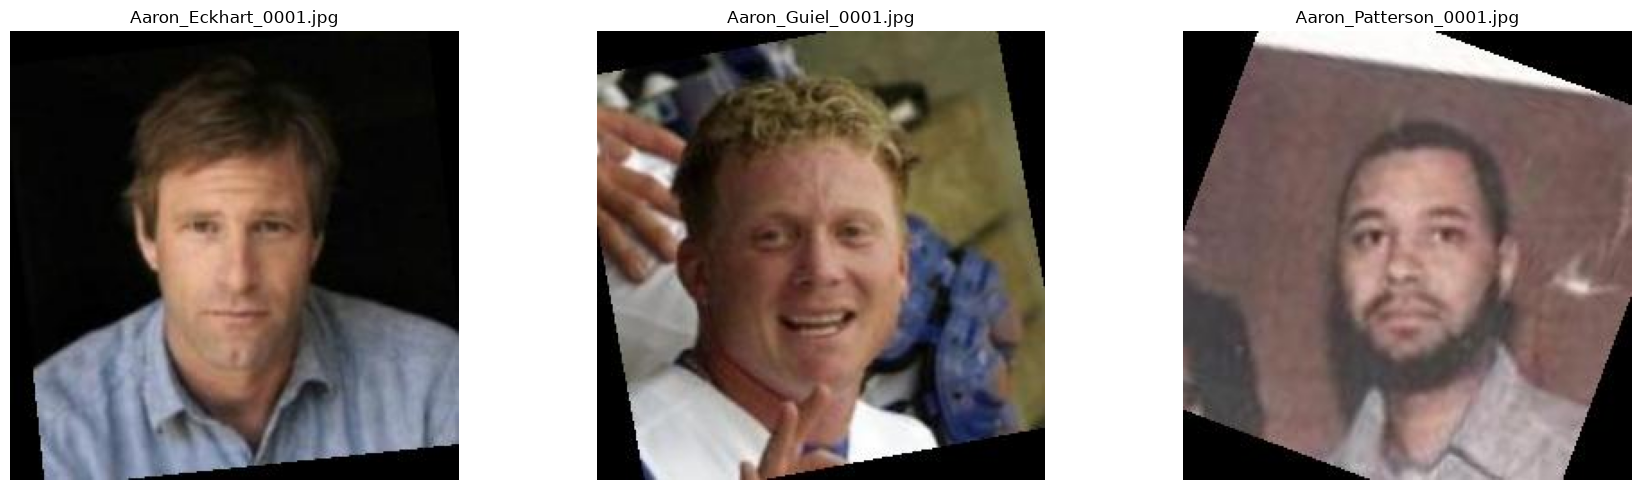

In [4]:
fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(6 * len(IMAGE_PATHS), 5))
axes = np.atleast_1d(axes)

for axis, image_path in zip(axes, IMAGE_PATHS):
    image_bgr = cv2.imread(str(image_path))
    assert image_bgr is not None, f"OpenCV 无法读取图片：{image_path}"
    axis.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    axis.set_title(image_path.name)
    axis.axis("off")

plt.tight_layout()
plt.show()

## 3. 下载并初始化 YuNet

In [5]:
MODEL_PATH = MODEL_DIR / "face_detection_yunet_2023mar.onnx"
MODEL_URL = (
    "https://github.com/opencv/opencv_zoo/raw/main/models/"
    "face_detection_yunet/face_detection_yunet_2023mar.onnx"
)

if not MODEL_PATH.exists():
    print("正在下载 YuNet 模型……")
    urlretrieve(MODEL_URL, MODEL_PATH)

assert MODEL_PATH.stat().st_size > 100_000, f"模型文件不完整：{MODEL_PATH}"
print("模型文件：", MODEL_PATH)

正在下载 YuNet 模型……
模型文件： D:\InternProject\face-vision-lab\data\models\face_detection_yunet_2023mar.onnx


In [6]:
SCORE_THRESHOLD = 0.60
NMS_THRESHOLD = 0.30
TOP_K = 5000

detector = cv2.FaceDetectorYN.create(
    str(MODEL_PATH), "", (320, 320),
    SCORE_THRESHOLD, NMS_THRESHOLD, TOP_K,
)

print("YuNet 初始化完成")

YuNet 初始化完成


## 4. 执行人脸检测与关键点定位

每个结果包含 15 个数：人脸框 `(x, y, w, h)`、5 个关键点坐标和置信度。

In [7]:
prediction_items = []
start_time = perf_counter()

for image_path in IMAGE_PATHS:
    image_bgr = cv2.imread(str(image_path))
    assert image_bgr is not None
    height, width = image_bgr.shape[:2]
    detector.setInputSize((width, height))
    _, faces = detector.detect(image_bgr)
    faces = np.empty((0, 15), dtype=np.float32) if faces is None else faces
    assert faces.ndim == 2 and faces.shape[1] == 15
    prediction_items.append({
        "image_path": image_path,
        "image_bgr": image_bgr,
        "faces": faces,
    })

inference_seconds = perf_counter() - start_time
print(f"总推理时间：{inference_seconds:.3f} 秒")
print(f"平均每张：{inference_seconds / len(IMAGE_PATHS):.3f} 秒")
for item in prediction_items:
    print(f"{item['image_path'].name}: {len(item['faces'])} 张人脸")

总推理时间：0.013 秒
平均每张：0.004 秒
Aaron_Eckhart_0001.jpg: 1 张人脸
Aaron_Guiel_0001.jpg: 1 张人脸
Aaron_Patterson_0001.jpg: 1 张人脸


## 5. 使用 OpenCV 绘制并保存结果

绿色矩形表示人脸框；数字 1–5 分别表示右眼、左眼、鼻尖、右嘴角和左嘴角。

关键点结果已保存： D:\InternProject\face-vision-lab\face_recognition\outputs\face_landmarks\Aaron_Eckhart_0001_face_landmarks.jpg
关键点结果已保存： D:\InternProject\face-vision-lab\face_recognition\outputs\face_landmarks\Aaron_Guiel_0001_face_landmarks.jpg
关键点结果已保存： D:\InternProject\face-vision-lab\face_recognition\outputs\face_landmarks\Aaron_Patterson_0001_face_landmarks.jpg


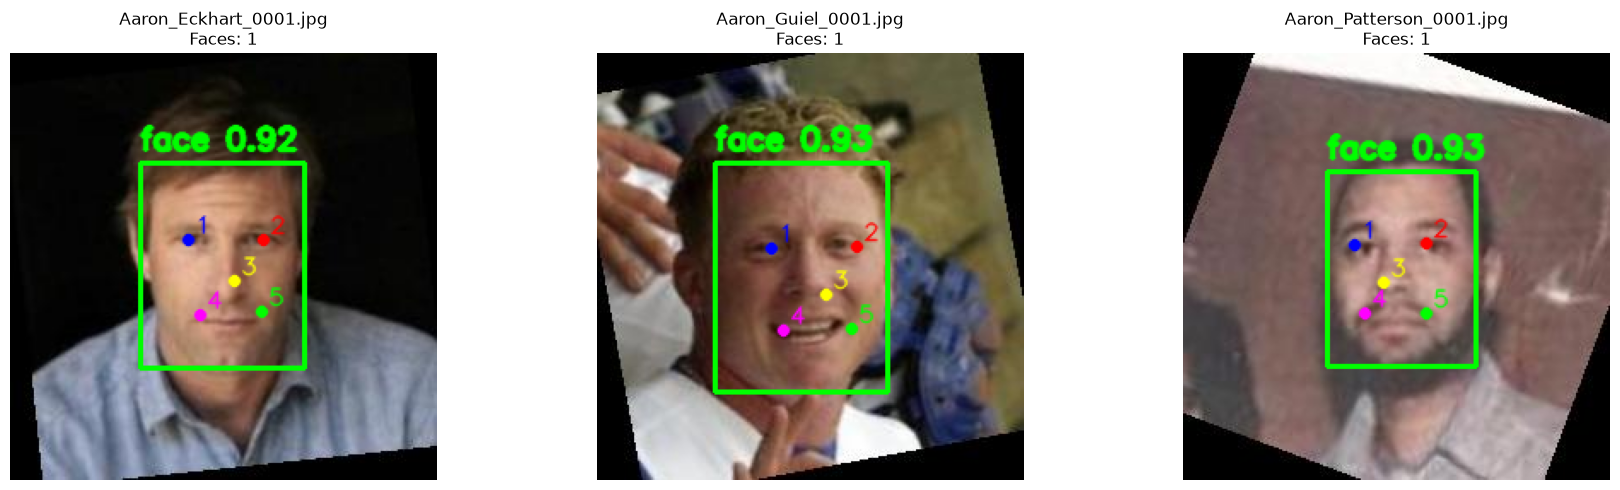

In [8]:
LANDMARK_NAMES = ["right_eye", "left_eye", "nose_tip", "right_mouth", "left_mouth"]
LANDMARK_COLORS = [(255, 0, 0), (0, 0, 255), (0, 255, 255), (255, 0, 255), (0, 255, 0)]
landmark_rows = []

fig, axes = plt.subplots(1, len(prediction_items), figsize=(6 * len(prediction_items), 5))
axes = np.atleast_1d(axes)

for axis, item in zip(axes, prediction_items):
    annotated_bgr = item["image_bgr"].copy()

    for face_id, face in enumerate(item["faces"], start=1):
        x, y, width, height = np.rint(face[:4]).astype(int)
        landmarks = face[4:14].reshape(5, 2)
        score = float(face[14])

        cv2.rectangle(annotated_bgr, (x, y), (x + width, y + height), (0, 255, 0), 2)
        cv2.putText(
            annotated_bgr, f"face {score:.2f}", (x, max(y - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA,
        )

        for point_id, (name, point, color) in enumerate(
            zip(LANDMARK_NAMES, landmarks, LANDMARK_COLORS), start=1
        ):
            px, py = np.rint(point).astype(int)
            cv2.circle(annotated_bgr, (px, py), 3, color, -1, cv2.LINE_AA)
            cv2.putText(
                annotated_bgr, str(point_id), (px + 4, py - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA,
            )
            landmark_rows.append({
                "image": item["image_path"].name,
                "face_id": face_id,
                "landmark": name,
                "x": px,
                "y": py,
                "face_score": round(score, 4),
            })

    result_path = OUTPUT_DIR / f"{item['image_path'].stem}_face_landmarks.jpg"
    assert cv2.imwrite(str(result_path), annotated_bgr), f"无法保存：{result_path}"
    axis.imshow(cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB))
    axis.set_title(f"{item['image_path'].name}\nFaces: {len(item['faces'])}")
    axis.axis("off")
    print("关键点结果已保存：", result_path)

plt.tight_layout()
plt.show()

## 6. 查看关键点坐标

In [9]:
landmarks_df = pd.DataFrame(
    landmark_rows,
    columns=["image", "face_id", "landmark", "x", "y", "face_score"],
)

landmarks_df

,image,face_id,landmark,x,y,face_score
0,Aaron_Eckhart_0001.jpg,1,right_eye,104,109,0.9204
1,Aaron_Eckhart_0001.jpg,1,left_eye,148,109,0.9204
2,Aaron_Eckhart_0001.jpg,1,nose_tip,131,133,0.9204
3,Aaron_Eckhart_0001.jpg,1,right_mouth,111,153,0.9204
4,Aaron_Eckhart_0001.jpg,1,left_mouth,147,151,0.9204
5,Aaron_Guiel_0001.jpg,1,right_eye,102,114,0.9336
6,Aaron_Guiel_0001.jpg,1,left_eye,152,113,0.9336
7,Aaron_Guiel_0001.jpg,1,nose_tip,134,141,0.9336
8,Aaron_Guiel_0001.jpg,1,right_mouth,109,162,0.9336
9,Aaron_Guiel_0001.jpg,1,left_mouth,149,161,0.9336


# 第二部分：LFW 人脸验证

## 7. 下载并初始化 SFace


In [10]:
SFACE_MODEL_PATH = MODEL_DIR / "face_recognition_sface_2021dec.onnx"
SFACE_MODEL_URL = (
    "https://github.com/opencv/opencv_zoo/raw/main/models/"
    "face_recognition_sface/face_recognition_sface_2021dec.onnx"
)

if not SFACE_MODEL_PATH.exists():
    print("正在下载 SFace 模型……")
    urlretrieve(SFACE_MODEL_URL, SFACE_MODEL_PATH)

assert SFACE_MODEL_PATH.stat().st_size > 10_000_000, f"模型文件不完整：{SFACE_MODEL_PATH}"
recognizer = cv2.FaceRecognizerSF.create(str(SFACE_MODEL_PATH), "")
print("SFace 初始化完成：", SFACE_MODEL_PATH)

正在下载 SFace 模型……
SFace 初始化完成： D:\InternProject\face-vision-lab\data\models\face_recognition_sface_2021dec.onnx


## 8. 读取 LFW 验证配对

仓库中的 `pairs.csv` 包含 6000 对图片：3000 对属于同一个人，3000 对属于不同的人。原始顺序每 600 对构成一折，共 10 折。

In [11]:
LFW_DIR = PROJECT_ROOT / "data" / "lfw" / "lfw-deepfunneled"
PAIRS_PATH = PROJECT_ROOT / "data" / "lfw" / "pairs.csv"
assert LFW_DIR.exists(), f"找不到 LFW 图片目录：{LFW_DIR}"
assert PAIRS_PATH.exists(), f"找不到 LFW 配对文件：{PAIRS_PATH}"

raw_pairs = pd.read_csv(PAIRS_PATH, dtype=str).fillna("")
pair_rows = []

for pair_index, row in enumerate(raw_pairs.itertuples(index=False, name=None)):
    name1, image_num1, third_value, fourth_value = row
    if fourth_value:
        name2, image_num2, is_same = third_value, fourth_value, 0
    else:
        name2, image_num2, is_same = name1, third_value, 1

    path1 = LFW_DIR / name1 / f"{name1}_{int(image_num1):04d}.jpg"
    path2 = LFW_DIR / name2 / f"{name2}_{int(image_num2):04d}.jpg"
    pair_rows.append({
        "fold": pair_index // 600 + 1,
        "path1": path1,
        "path2": path2,
        "is_same": is_same,
    })

pairs_df = pd.DataFrame(pair_rows)
assert len(pairs_df) == 6000
assert pairs_df["is_same"].value_counts().to_dict() == {1: 3000, 0: 3000}
assert all(path.exists() for path in set(pairs_df["path1"]) | set(pairs_df["path2"]))

print("配对总数：", len(pairs_df))
print("同一人：", int(pairs_df["is_same"].sum()))
print("不同人：", int((1 - pairs_df["is_same"]).sum()))
pairs_df.head()

配对总数： 6000
同一人： 3000
不同人： 3000


,fold,path1,path2,is_same
0,1,D:\InternProject\face-vision-lab\data\lfw\lfw-...,D:\InternProject\face-vision-lab\data\lfw\lfw-...,1
1,1,D:\InternProject\face-vision-lab\data\lfw\lfw-...,D:\InternProject\face-vision-lab\data\lfw\lfw-...,1
2,1,D:\InternProject\face-vision-lab\data\lfw\lfw-...,D:\InternProject\face-vision-lab\data\lfw\lfw-...,1
3,1,D:\InternProject\face-vision-lab\data\lfw\lfw-...,D:\InternProject\face-vision-lab\data\lfw\lfw-...,1
4,1,D:\InternProject\face-vision-lab\data\lfw\lfw-...,D:\InternProject\face-vision-lab\data\lfw\lfw-...,1


## 9. 提取 LFW 人脸特征

In [13]:
def extract_face_feature(image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return None

    height, width = image_bgr.shape[:2]
    detector.setInputSize((width, height))
    _, faces = detector.detect(image_bgr)
    if faces is None or len(faces) == 0:
        return None

    face = faces[np.argmax(faces[:, 14])]
    aligned_face = recognizer.alignCrop(image_bgr, face)
    return recognizer.feature(aligned_face).copy()


unique_paths = sorted(set(pairs_df["path1"]) | set(pairs_df["path2"]))
feature_by_path = {}
failed_paths = []
feature_start = perf_counter()

for image_index, image_path in enumerate(unique_paths, start=1):
    feature = extract_face_feature(image_path)
    if feature is None:
        failed_paths.append(image_path)
    else:
        feature_by_path[image_path] = feature

    if image_index % 500 == 0 or image_index == len(unique_paths):
        print(f"已处理 {image_index}/{len(unique_paths)} 张图片")

feature_seconds = perf_counter() - feature_start
print(f"特征提取时间：{feature_seconds:.1f} 秒")
print(f"成功：{len(feature_by_path)}，失败：{len(failed_paths)}")

已处理 500/7701 张图片
已处理 1000/7701 张图片
已处理 1500/7701 张图片
已处理 2000/7701 张图片
已处理 2500/7701 张图片
已处理 3000/7701 张图片
已处理 3500/7701 张图片
已处理 4000/7701 张图片
已处理 4500/7701 张图片
已处理 5000/7701 张图片
已处理 5500/7701 张图片
已处理 6000/7701 张图片
已处理 6500/7701 张图片
已处理 7000/7701 张图片
已处理 7500/7701 张图片
已处理 7701/7701 张图片
特征提取时间：121.6 秒
成功：7701，失败：0


## 10. 计算验证准确率

使用 SFace 官方 LFW 余弦相似度阈值 `0.363`。相似度大于或等于该阈值时，预测两张图片属于同一个人。无法检测到人脸的配对不会进入准确率计算，同时会单独报告有效覆盖率。

In [14]:
COSINE_THRESHOLD = 0.363
verification_rows = []

for pair in pairs_df.itertuples(index=False):
    feature1 = feature_by_path.get(pair.path1)
    feature2 = feature_by_path.get(pair.path2)
    if feature1 is None or feature2 is None:
        continue

    similarity = float(recognizer.match(
        feature1, feature2, cv2.FaceRecognizerSF_FR_COSINE
    ))
    predicted_same = int(similarity >= COSINE_THRESHOLD)
    verification_rows.append({
        "fold": pair.fold,
        "is_same": pair.is_same,
        "predicted_same": predicted_same,
        "similarity": similarity,
        "correct": int(predicted_same == pair.is_same),
    })

verification_results = pd.DataFrame(verification_rows)
assert not verification_results.empty, "没有可用于验证的人脸配对"

coverage = len(verification_results) / len(pairs_df)
accuracy = verification_results["correct"].mean()
fold_accuracy = verification_results.groupby("fold")["correct"].mean()

print(f"有效配对：{len(verification_results)}/{len(pairs_df)}")
print(f"有效覆盖率：{coverage:.2%}")
print(f"LFW 验证准确率：{accuracy:.2%}")
print(f"10 折平均准确率：{fold_accuracy.mean():.2%} ± {fold_accuracy.std(ddof=1):.2%}")

pd.DataFrame({"accuracy": fold_accuracy}).style.format("{:.2%}")

有效配对：6000/6000
有效覆盖率：100.00%
LFW 验证准确率：97.22%
10 折平均准确率：97.22% ± 0.60%


,accuracy
fold,
1,98.17%
2,97.00%
3,96.50%
4,97.17%
5,97.33%
6,98.17%
7,97.33%
8,97.00%
9,96.33%


## 11. 扩展评估指标

除 Accuracy 外，进一步计算 Precision、Recall、F1、Specificity 和 ROC-AUC，并展示混淆矩阵、相似度分布和 ROC 曲线。这里将“同一个人”作为正类。

,metric,value
0,Accuracy,0.9722
1,Precision,0.9996
2,Recall,0.9447
3,F1 Score,0.9714
4,Specificity,0.9997
5,ROC-AUC,0.9772


,predicted_different,predicted_same
actual_different,2999,1
actual_same,166,2834


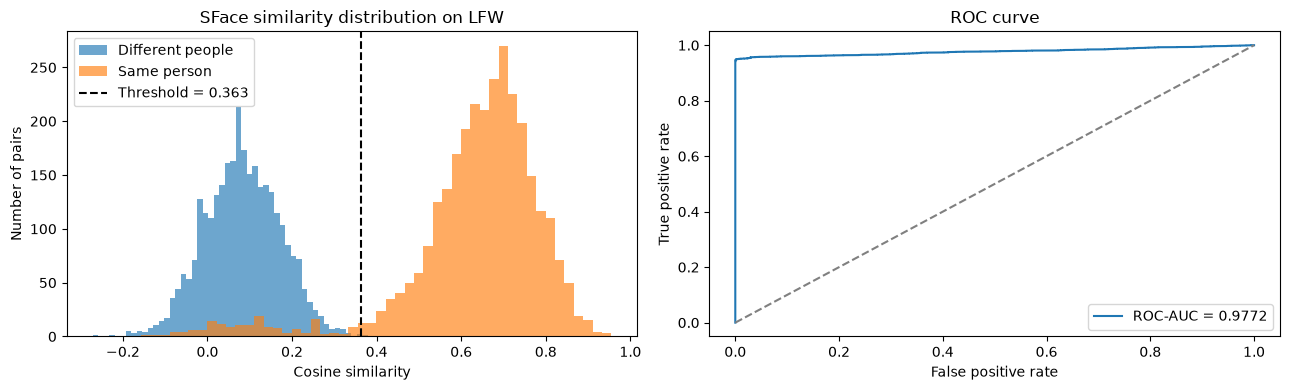

In [16]:
actual = verification_results["is_same"]
predicted = verification_results["predicted_same"]

tp = int(((actual == 1) & (predicted == 1)).sum())
tn = int(((actual == 0) & (predicted == 0)).sum())
fp = int(((actual == 0) & (predicted == 1)).sum())
fn = int(((actual == 1) & (predicted == 0)).sum())

precision = tp / (tp + fp) if tp + fp else 0.0
recall = tp / (tp + fn) if tp + fn else 0.0
specificity = tn / (tn + fp) if tn + fp else 0.0
f1_score = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

positive_count = int((actual == 1).sum())
negative_count = int((actual == 0).sum())
score_ranks = verification_results["similarity"].rank(method="average")
roc_auc = (
    score_ranks[actual == 1].sum() - positive_count * (positive_count + 1) / 2
) / (positive_count * negative_count)

metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Specificity", "ROC-AUC"],
    "value": [accuracy, precision, recall, f1_score, specificity, roc_auc],
})
assert metrics["value"].between(0, 1).all()
display(metrics.style.format({"value": "{:.4f}"}))

confusion_matrix = pd.crosstab(actual, predicted).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
confusion_matrix.index = ["actual_different", "actual_same"]
confusion_matrix.columns = ["predicted_different", "predicted_same"]
display(confusion_matrix)

same_scores = verification_results.loc[verification_results["is_same"] == 1, "similarity"]
different_scores = verification_results.loc[verification_results["is_same"] == 0, "similarity"]
sorted_indices = np.argsort(-verification_results["similarity"].to_numpy())
sorted_labels = actual.to_numpy()[sorted_indices]
true_positive_rate = np.r_[0.0, np.cumsum(sorted_labels) / positive_count]
false_positive_rate = np.r_[0.0, np.cumsum(1 - sorted_labels) / negative_count]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(different_scores, bins=50, alpha=0.65, label="Different people")
axes[0].hist(same_scores, bins=50, alpha=0.65, label="Same person")
axes[0].axvline(COSINE_THRESHOLD, color="black", linestyle="--", label=f"Threshold = {COSINE_THRESHOLD}")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Number of pairs")
axes[0].set_title("SFace similarity distribution on LFW")
axes[0].legend()

axes[1].plot(false_positive_rate, true_positive_rate, label=f"ROC-AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. 实验结论

本实验完成了以下工作：
1. 使用 OpenCV 加载 YuNet ONNX 预训练模型
2. 对多张测试图片进行人脸检测
3. 为每张人脸定位双眼、鼻尖和左右嘴角共 5 个关键点
4. 使用 OpenCV 绘制人脸框、置信度和关键点
5. 保存可视化结果，并将关键点坐标整理为表格
6. 使用 SFace 预训练模型提取 LFW 人脸特征
7. 在 6000 个 LFW 配对上计算覆盖率、验证准确率和 10 折准确率
8. 计算 Precision、Recall、F1、Specificity 和 ROC-AUC，并绘制混淆矩阵与 ROC 曲线

### 局限性

- YuNet 只输出 5 个稀疏关键点，不能描述完整的脸部轮廓
- 遮挡、极端侧脸、模糊和低分辨率可能降低定位精度
- 如果后续特效需要眉毛、下颌线等稠密点，可再使用 MediaPipe Face Mesh 或 68/106 点模型
- 本实验使用官方固定阈值，没有利用当前数据重新搜索最优阈值
- 如果 YuNet 未检测到某张脸，包含该图片的配对会被跳过，并反映在有效覆盖率中

## 参考资料

1. [OpenCV：DNN-based Face Detection and Recognition](https://docs.opencv.org/4.11.0/d0/dd4/tutorial_dnn_face.html)
2. [OpenCV Zoo：YuNet](https://github.com/opencv/opencv_zoo/tree/main/models/face_detection_yunet)
3. [OpenCV Zoo：SFace](https://github.com/opencv/opencv_zoo/tree/main/models/face_recognition_sface)
4. Wu et al., [YuNet: A Tiny Millisecond-level Face Detector](https://link.springer.com/article/10.1007/s11633-023-1423-y)